In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import geopandas as gpd
import rioxarray
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

In [11]:
t1=xr.open_dataset('/storage/GLDAS_2.0/GLDAS_CLSM025_D.A20141230.020.nc4').drop_vars('time_bnds')

<xarray.Dataset> Size: 114MB
Dimensions:            (lat: 600, lon: 1440, time: 1)
Coordinates:
  * lat                (lat) float32 2kB -59.88 -59.62 -59.38 ... 89.62 89.88
  * lon                (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
  * time               (time) datetime64[ns] 8B 2014-12-30
Data variables: (12/33)
    Swnet_tavg         (time, lat, lon) float32 3MB ...
    Lwnet_tavg         (time, lat, lon) float32 3MB ...
    Qle_tavg           (time, lat, lon) float32 3MB ...
    Qh_tavg            (time, lat, lon) float32 3MB ...
    Qg_tavg            (time, lat, lon) float32 3MB ...
    Snowf_tavg         (time, lat, lon) float32 3MB ...
    ...                 ...
    Rainf_f_tavg       (time, lat, lon) float32 3MB ...
    Tair_f_tavg        (time, lat, lon) float32 3MB ...
    Qair_f_tavg        (time, lat, lon) float32 3MB ...
    Psurf_f_tavg       (time, lat, lon) float32 3MB ...
    SWdown_f_tavg      (time, lat, lon) float32 3MB ...
    LWdown_f_tavg      (time, lat, lon) float32 3MB ...
Attributes: (12/14)
    missing_value:          -9999.0
    tavg definision::       24-hour average
    title:                  LIS land surface model output
    institution:            NASA GSFC HSL
    source:                 CLSM_F2.5
    history:                created on date: 2017-06-14T07:29:23.794
    ...                     ...
    comment:                website: http://ldas.gsfc.nasa.gov/gldas, http://...
    MAP_PROJECTION:         EQUIDISTANT CYLINDRICAL
    SOUTH_WEST_CORNER_LAT:  -59.875
    SOUTH_WEST_CORNER_LON:  -179.875
    DX:                     0.25
    DY:                     0.25

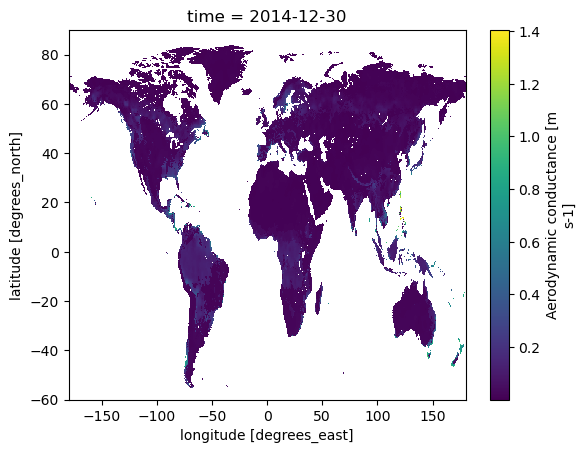

In [12]:
t1['ACond_tavg'].plot()

In [ ]:
tif_path='./shapefiles/kg-climate/kg-beck/1991_2020/koppen_geiger_0p5.tif'
temp_kg=rioxarray.open_rasterio(tif_path)
temp_kg=temp_kg.sortby('y').drop(['spatial_ref', 'band'])

/tmp/ipykernel_20764/1092798077.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  temp_kg=temp_kg.sortby('y').drop(['spatial_ref', 'band'])


<xarray.DataArray (band: 1, y: 360, x: 720)> Size: 259kB
[259200 values with dtype=uint8]
Coordinates:
  * x        (x) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
  * y        (y) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
Dimensions without coordinates: band
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0

In [ ]:
temp_basins=gpd.read_file('./shapefiles/mrb_shp_zip/mrb_basins.shp');

In [ ]:
temp_river_nw=gpd.read_file('./shapefiles/mrb_shp_zip/mrb_rivnets_Q09_10.shp');

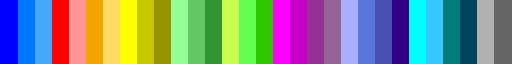

In [ ]:
temp_df=pd.read_csv('./shapefiles/kg-climate/kg-beck/color_codes.csv', index_col=0,
                    skipinitialspace=True);
rgb_codes=[temp_df['RGB code'].iloc[k].replace(' ',',') for k in range(len(temp_df))]
for k in range(len(rgb_codes)):
    rgb_codes[k]=tuple(map(int,rgb_codes[k].replace('[','').replace(']','').split(',')))
rgb_codes = [(round(r/256, 4), round(g/256, 4), round(b/256, 4)) for r, g, b in rgb_codes];
custom_cmap = mcolors.ListedColormap(rgb_codes)

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0, globe=None)},
                       figsize=(10, 6), dpi=150)
temp_kg.plot(cmap=custom_cmap, ax=ax, transform=ccrs.PlateCarree(), add_colorbar=True, zorder=1)
temp_river_nw.plot(ax=ax, color='k', transform=ccrs.PlateCarree(), lw=0.4, zorder=2)
temp_basins.plot(ax=ax, transform=ccrs.PlateCarree(), facecolor='none', edgecolor='violet', lw=0.4, zorder=2)
ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=1, xlocs=np.arange(-180, 181, 5), ylocs=np.arange(-60, 81, 5))

#### Make plots

In [18]:
regions = {
    "Ganges": {
        "extent": [75, 90, 20, 30],     # (lon_min, lon_max, lat_min, lat_max)
        "coords": [[78.875, 24.375], [82.125, 23.875], [82.875, 27.625], [79.125, 23.875], [88.875, 25.375]]
    },
    "Amazon": {
        "extent": [-80, -50, -15, 5],
        "coords": [[-64.625, 0.875], [-73.125, -6.875], [-60.125, -2.375], [-60.625, -4.125], [-66.625, -3.125],
                    [-53.625,-3.625], [-64.125,-6.875], [-55.125,1.375], [-59.875,-7.125], [-72.125,-10.125]]
    },
    "Murray": {
        "extent": [140, 150, -40, -25],
        "coords": [[140.125, -33.125], [143.125, -32.375], [145.125, -29.625], [144.375, -33.625], [144.375, -28.125],
                   [148.125,-29.125], [146.625,-31.375], [146.875,-25.875], [147.125,-27.375], [150.875,-28.125],
                   ]
    },
    "Danube": {
        "extent": [30, 15, 40, 50],
        "coords": [[26.125, 46.875], [18.875, 48.625], [15.325, 47.625], [19.875, 43.325], [16.875, 49.375],
                   [16.625,45.875],  [17.625,46.625],  [20.325,44.325], [23.125,43.325], [26.325,42.325],
                   ]
    },
    "Mississippi": {
        "extent": [-110, -80, 30, 50],
        "coords": [[-92.875, 37.125], [-93.375, 32.625], [-98.125, 34.625], [-86.625, 35.125], [-82.875, 37.125],
                    [-92.875, 39.875], [-95.625, 42.625], [-88.625, 40.125], [-92.875, 43.825], [-98.325, 42.125],
                    ]
    }
};

In [ ]:
matplotlib.rcParams['font.family'] = 'Times New Roman'

for region_name, region_data in regions.items():
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0, globe=None)}, figsize=(3, 3), dpi=70)
    ax.add_feature(cartopy.feature.OCEAN, edgecolor='k', facecolor='whitesmoke', lw=0.5, zorder=10)
    temp_kg.plot(cmap=custom_cmap, ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, zorder=1)
    temp_river_nw.plot(ax=ax, color='k', transform=ccrs.PlateCarree(), lw=0.7, zorder=2)
    temp_basins.plot(ax=ax, transform=ccrs.PlateCarree(), facecolor='none', edgecolor='violet', lw=0.8, zorder=2)

    ax.set_extent(region_data["extent"])

    for lon, lat in region_data["coords"]:
        ax.plot(lon, lat, marker='*', color='gold', markersize=12, markeredgecolor='k', transform=ccrs.PlateCarree(), zorder=8)

    ax.gridlines(draw_labels=True, linewidth=0.7, color='grey', alpha=0.5,
             xlocs=np.arange(-180, 181, 5), ylocs=np.arange(-90, 91, 2.5),
                 xlabel_style={'size': 10}, ylabel_style={'size': 10}, zorder=10)

    ax.text(-0.22, 0.5, f'{region_name}', transform=ax.transAxes, fontsize=12, rotation=90, verticalalignment='center',
        horizontalalignment='center')
    plt.savefig(f'./ci_eval/plots/figs/regions_plot/t__{region_name.lower()}.png', 
                dpi=400, bbox_inches='tight', pad_inches=0.0)
    plt.tight_layout()
    plt.show()

In [ ]:
# make individual plots for Murray region
matplotlib.rcParams['font.family'] = 'Times New Roman'

region_name, region_data = 'Murray', regions['Murray']
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0, globe=None)}, figsize=(2, 2), dpi=70)
ax.add_feature(cartopy.feature.OCEAN, edgecolor='k', facecolor='whitesmoke', lw=0.5, zorder=10)
temp_kg.plot(cmap=custom_cmap, ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, zorder=1)
temp_river_nw.plot(ax=ax, color='k', transform=ccrs.PlateCarree(), lw=0.7, zorder=2)
temp_basins.plot(ax=ax, transform=ccrs.PlateCarree(), facecolor='none', edgecolor='violet', lw=0.8, zorder=2)

ax.set_extent(region_data["extent"])

for lon, lat in region_data["coords"]:
    ax.plot(lon, lat, marker='*', color='gold', markersize=12, markeredgecolor='k', transform=ccrs.PlateCarree(), zorder=8)

ax.gridlines(draw_labels=True, linewidth=0.7, color='grey', alpha=0.5,
            xlocs=np.arange(-180, 181, 5), ylocs=np.arange(-90, 91, 2.5),
                xlabel_style={'size': 10}, ylabel_style={'size': 10}, zorder=10)

ax.text(-0.35, 0.5, f'{region_name}', transform=ax.transAxes, fontsize=12, rotation=90, verticalalignment='center',
    horizontalalignment='center')
plt.savefig(f'./ci_eval/plots/figs/regions_plot/t__{region_name.lower()}.png', 
            dpi=400, bbox_inches='tight', pad_inches=0.0)
plt.tight_layout()
plt.show()

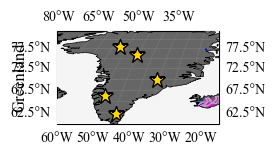

In [ ]:
# make individual plots for Murray region
matplotlib.rcParams['font.family'] = 'Times New Roman'

region_name, region_data = 'Greenland', regions['Greenland']
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson(central_longitude=0, globe=None)}, figsize=(3, 3), dpi=100)
ax.add_feature(cartopy.feature.OCEAN, edgecolor='k', facecolor='whitesmoke', lw=0.5, zorder=10)
temp_kg.plot(cmap=custom_cmap, ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, zorder=1)
temp_river_nw.plot(ax=ax, color='k', transform=ccrs.PlateCarree(), lw=0.7, zorder=2)
temp_basins.plot(ax=ax, transform=ccrs.PlateCarree(), facecolor='none', edgecolor='violet', lw=0.8, zorder=2)

ax.set_extent(region_data["extent"])

for lon, lat in region_data["coords"]:
    ax.plot(lat, lon, marker='*', color='gold', markersize=12, markeredgecolor='k', transform=ccrs.PlateCarree(), zorder=8)

ax.gridlines(draw_labels=True, linewidth=0.7, color='grey', alpha=0.5,
            xlocs=np.arange(-180, 181, 5), ylocs=np.arange(-90, 91, 2.5),
                xlabel_style={'size': 10}, ylabel_style={'size': 10}, zorder=10)

ax.text(-0.23, 0.5, f'{region_name}', transform=ax.transAxes, fontsize=12, rotation=90, verticalalignment='center',
    horizontalalignment='center')
plt.savefig(f'./ci_eval/plots/figs/regions_plot/t__{region_name.lower()}.png', 
            dpi=400, bbox_inches='tight', pad_inches=0.0)
plt.tight_layout()
plt.show()